In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from tqdm import tqdm

In [2]:
# Load the datasets
train_df = pd.read_csv('drDataset/train_metadata.csv')
val_df = pd.read_csv('drDataset/val_metadata.csv')

# Combine for a total distribution analysis
all_data = pd.concat([train_df, val_df], ignore_index=True)

print(f"Total Images for Analysis: {len(all_data)}")
print(all_data.head())

Total Images for Analysis: 19729
                        image_id  dr_grade     source
0  MS_20051202_55816_0400_PP.png         2  Messidor2
1      DDR_20170401171223455.jpg         0        DDR
2           DDR_007-4674-200.jpg         2        DDR
3      DDR_20170502103235986.jpg         3        DDR
4  MS_20060523_43174_0100_PP.png         2  Messidor2


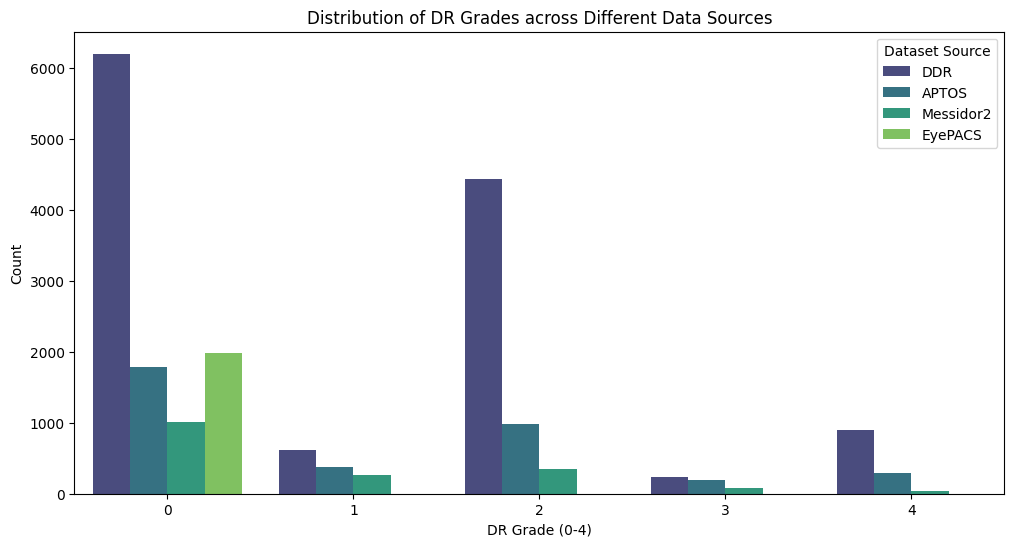

dr_grade      0    1     2    3    4
source                              
APTOS      1783  370   987  190  291
DDR        6205  622  4433  234  905
EyePACS    1980    0     0    0    0
Messidor2  1009  265   345   75   35


In [3]:
plt.figure(figsize=(12, 6))
sns.countplot(data=all_data, x='dr_grade', hue='source', palette='viridis')
plt.title('Distribution of DR Grades across Different Data Sources')
plt.xlabel('DR Grade (0-4)')
plt.ylabel('Count')
plt.legend(title='Dataset Source')
plt.show()

# Print exact numbers for the report
print(pd.crosstab(all_data['source'], all_data['dr_grade']))

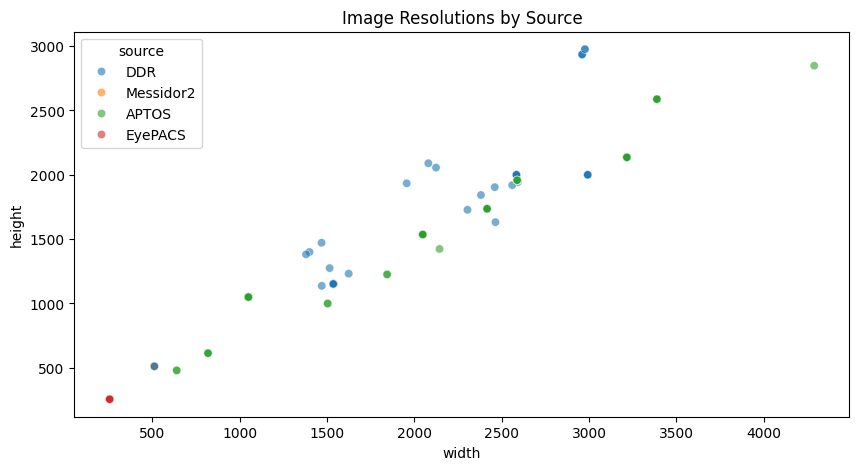

Average Aspect Ratio: 1.09


In [5]:
def get_dims(path, img_id):
    # Adjust path based on your folder structure
    full_path = os.path.join('drDataset/train', img_id) 
    img = cv2.imread(full_path)
    if img is not None:
        return img.shape[0], img.shape[1]
    return None, None

# Sample 500 images to save time, or run on all if you have time
sample_df = all_data.sample(500)
sample_df['height'], sample_df['width'] = zip(*sample_df.apply(lambda x: get_dims('train', x['image_id']), axis=1))
sample_df['aspect_ratio'] = sample_df['width'] / sample_df['height']

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample_df, x='width', y='height', hue='source', alpha=0.6)
plt.title('Image Resolutions by Source')
plt.show()

print(f"Average Aspect Ratio: {sample_df['aspect_ratio'].mean():.2f}")

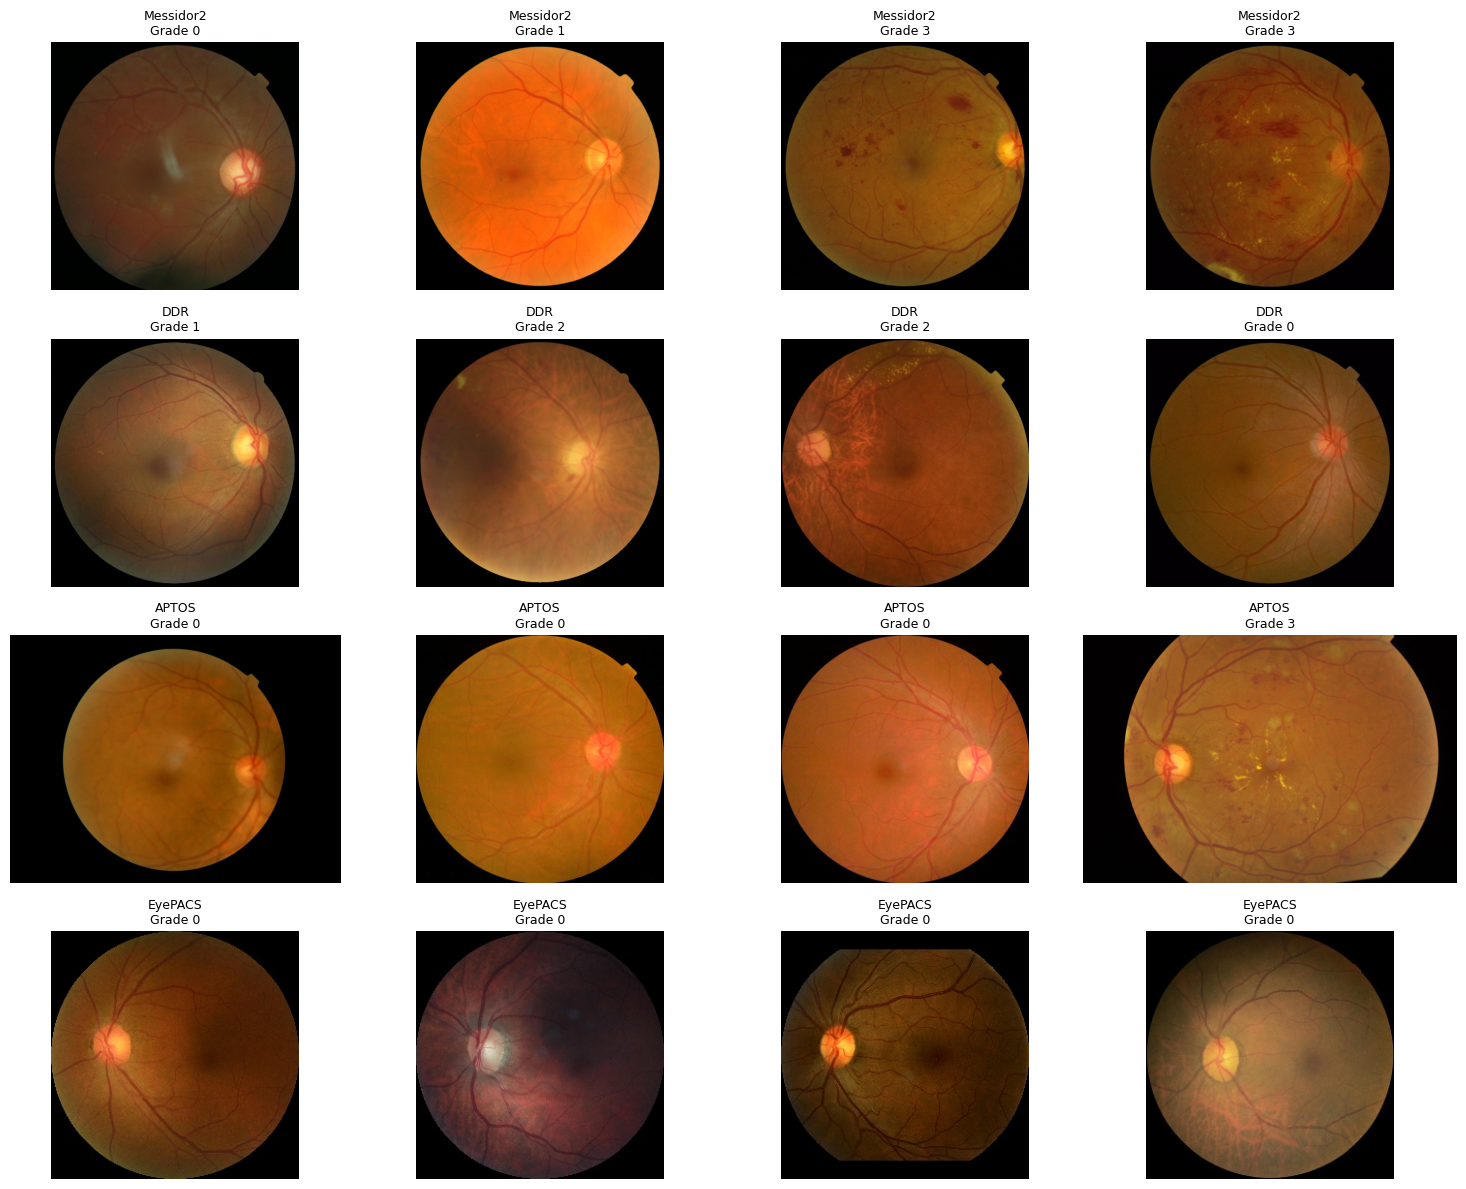

In [7]:
def plot_source_samples(df, n=4):
    sources = df['source'].unique()
    fig, axes = plt.subplots(len(sources), n, figsize=(15, 12))
    
    for i, source in enumerate(sources):
        # Filter by source and sample safely
        subset = df[df['source'] == source]
        sampled_rows = subset.sample(min(n, len(subset)))
        
        for j, (_, row) in enumerate(sampled_rows.iterrows()):
            # Check both possible folders
            path_train = os.path.join('drDataset/train', row['image_id'])
            path_val = os.path.join('drDataset/val', row['image_id'])
            
            img_path = path_train if os.path.exists(path_train) else path_val
            
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"{source}\nGrade {row['dr_grade']}", fontsize=9)
            else:
                axes[i, j].text(0.5, 0.5, 'Image Not Found', ha='center')
            
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

plot_source_samples(all_data)